In [58]:
import numpy as np
import pandas as pd

In [59]:
df=pd.read_csv("housing.csv",encoding='utf-8')

In [60]:
housing=housing.drop("ocean_proximity",axis=1)

KeyError: "['ocean_proximity'] not found in axis"

In [ ]:
df['income_cat']=pd.cut(df['median_income'],bins=[0,1.5,3.0,4.5,6.0,np.inf],labels=[1,2,3,4,5])

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
split=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)

In [ ]:
for train_index,test_index in split.split(df,df['income_cat']):
    strata_train_set=df.loc[train_index];
    strata_test_set=df.loc[test_index]

In [ ]:
for sett in (strata_train_set,strata_test_set):
    sett.drop("income_cat",axis=1,inplace=True)

In [ ]:
strata_test_set


In [ ]:
strata_train_set

In [ ]:
df=strata_train_set.copy()

In [61]:
import matplotlib.pyplot as plt

<Axes: xlabel='latitude', ylabel='longitude'>

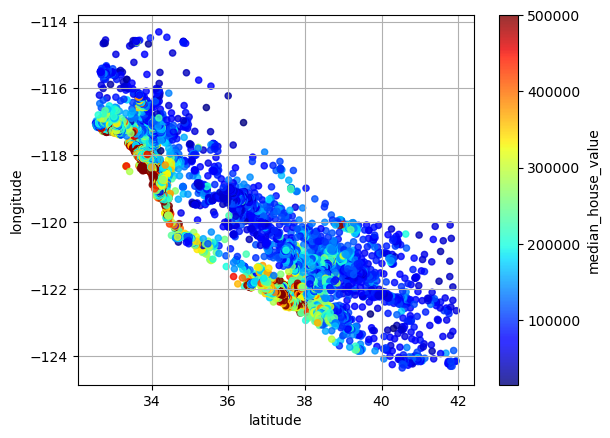

In [62]:
df.plot(kind="scatter",x="latitude",y="longitude",grid=True,alpha=0.8,cmap="jet",c="median_house_value")

In [63]:
from pandas.plotting import scatter_matrix

In [64]:
attributes=["housing_median_age","median_income","median_house_value"]

array([[<Axes: xlabel='housing_median_age', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='median_house_value', ylabel='housing_median_age'>],
       [<Axes: xlabel='housing_median_age', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='median_house_value', ylabel='median_income'>],
       [<Axes: xlabel='housing_median_age', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='median_house_value', ylabel='median_house_value'>]],
      dtype=object)

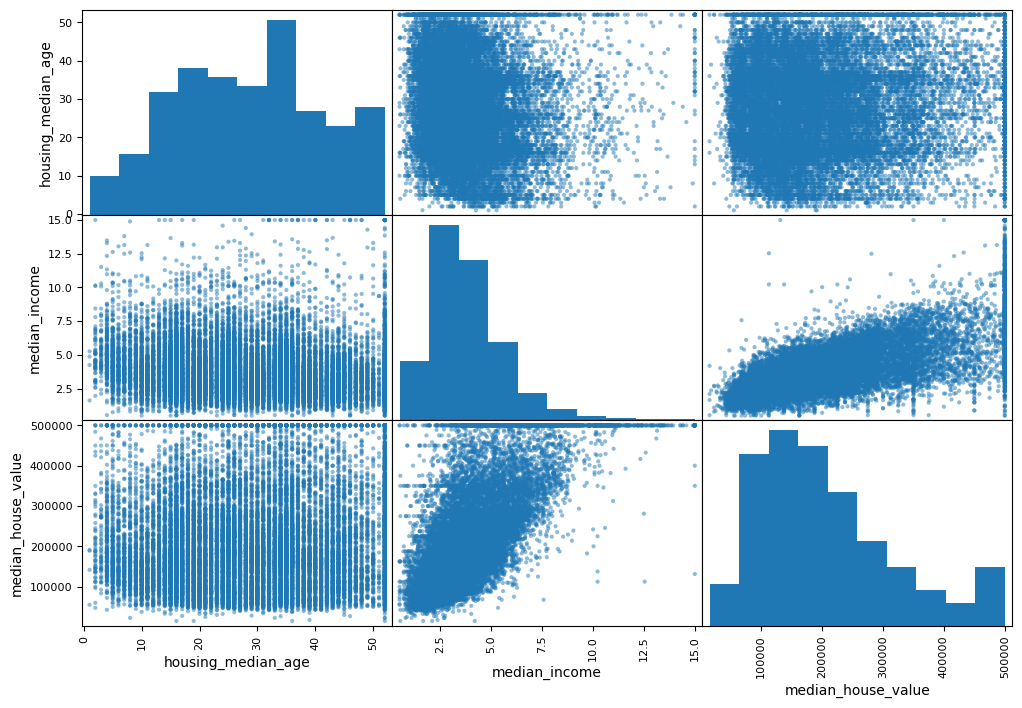

In [65]:
scatter_matrix(df[attributes],figsize=(12,8))

In [66]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [67]:
housing=strata_train_set.drop("median_house_value",axis=1)
housing_labels=strata_train_set["median_house_value"].copy()

In [68]:
housing_labels

12655     72100.0
15502    279600.0
2908      82700.0
14053    112500.0
20496    238300.0
           ...   
15174    268500.0
12661     90400.0
19263    140400.0
19140    258100.0
19773     62700.0
Name: median_house_value, Length: 16512, dtype: float64

In [69]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [70]:
from sklearn.impute import SimpleImputer

In [71]:
imputer=SimpleImputer(strategy="median")

In [72]:
housing['ocean_proximity']=df['ocean_proximity']

In [73]:
set(housing['ocean_proximity'])

{'<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'}

In [74]:
from sklearn.preprocessing import OrdinalEncoder #convert no integer value to integer value on tha basis of rating

In [75]:
ordinal_encoder = OrdinalEncoder()

In [76]:
housing_cat=ordinal_encoder.fit_transform(housing).copy()

In [77]:
housing_cat

array([[2.390e+02, 5.690e+02, 2.800e+01, ..., 7.040e+02, 1.815e+03,
        1.000e+00],
       [6.620e+02, 5.500e+01, 6.000e+00, ..., 7.660e+02, 9.519e+03,
        4.000e+00],
       [4.810e+02, 2.730e+02, 4.300e+01, ..., 2.980e+02, 3.475e+03,
        1.000e+00],
       ...,
       [1.130e+02, 5.610e+02, 4.700e+01, ..., 1.700e+02, 4.239e+03,
        0.000e+00],
       [1.150e+02, 5.480e+02, 1.300e+01, ..., 4.990e+02, 6.403e+03,
        0.000e+00],
       [1.710e+02, 7.010e+02, 2.600e+01, ..., 1.950e+02, 4.107e+03,
        1.000e+00]], shape=(16512, 9))

In [78]:
housing_cat=pd.DataFrame(housing_cat,columns=housing.columns,index=housing.index)

In [79]:
housing_cat

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
12655,239.0,569.0,28.0,3555.0,795.0,2167.0,704.0,1815.0,1.0
15502,662.0,55.0,6.0,4411.0,853.0,1965.0,766.0,9519.0,4.0
2908,481.0,273.0,43.0,1410.0,308.0,625.0,298.0,3475.0,1.0
14053,672.0,21.0,23.0,1669.0,517.0,856.0,481.0,1959.0,4.0
20496,515.0,174.0,26.0,3269.0,644.0,1791.0,578.0,6883.0,0.0
...,...,...,...,...,...,...,...,...,...
15174,678.0,49.0,13.0,4852.0,1208.0,1976.0,996.0,7805.0,0.0
12661,243.0,568.0,14.0,5072.0,1354.0,3353.0,1322.0,3341.0,1.0
19263,113.0,561.0,47.0,518.0,164.0,416.0,170.0,4239.0,0.0
19140,115.0,548.0,13.0,2924.0,578.0,1166.0,499.0,6403.0,0.0


In [80]:
#one hot encoding

In [81]:
from sklearn.preprocessing import OneHotEncoder


In [82]:
housing=housing[["ocean_proximity"]]

In [83]:
one_hot_encoder = OneHotEncoder()

In [84]:
housing_cat=one_hot_encoder.fit_transform(housing).copy()

In [85]:
housing_cat=housing_cat.toarray() #gives sparse matrix

In [86]:
one_hot_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [87]:
housing_cat=pd.DataFrame(housing_cat,columns=['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],index=housing.index)

In [88]:
##feature scaling


In [89]:
df=pd.concat([df,housing_cat],axis=1)

In [90]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,0.0,1.0,0.0,0.0,0.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,0.0,1.0,0.0,0.0,0.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,0.0,1.0,0.0,0.0,0.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,0.0,1.0,0.0,0.0,0.0


In [91]:
df=df.drop(columns="ocean_proximity")

In [92]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,0.0,1.0,0.0,0.0,0.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,0.0,1.0,0.0,0.0,0.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,0.0,1.0,0.0,0.0,0.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,0.0,1.0,0.0,0.0,0.0


In [93]:
from sklearn.preprocessing import MinMaxScaler

In [94]:
scaler= MinMaxScaler(feature_range=(-1,1))

In [95]:
df_scaled=scaler.fit_transform(df)


In [96]:
df_scaled=pd.DataFrame(df_scaled,columns=df.columns,index=df.index)

In [97]:
df_scaled

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-0.577689,0.134963,0.568627,-0.955339,-0.960273,-0.982118,-0.958888,0.079337,0.804533,-1.0,-1.0,-1.0,1.0,-1.0
1,-0.575697,0.130712,-0.215686,-0.638995,-0.657045,-0.865579,-0.626048,0.076054,0.416493,-1.0,-1.0,-1.0,1.0,-1.0
2,-0.579681,0.128587,1.000000,-0.925479,-0.941341,-0.972365,-0.942115,-0.067944,0.390101,-1.0,-1.0,-1.0,1.0,-1.0
3,-0.581673,0.128587,1.000000,-0.935297,-0.927374,-0.968889,-0.928301,-0.290603,0.345566,-1.0,-1.0,-1.0,1.0,-1.0
4,-0.581673,0.128587,1.000000,-0.917341,-0.913408,-0.968497,-0.915146,-0.538448,0.349277,-1.0,-1.0,-1.0,1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-0.350598,0.475027,-0.058824,-0.915408,-0.884233,-0.952801,-0.891794,-0.853740,-0.739791,-1.0,1.0,-1.0,-1.0,-1.0
20636,-0.374502,0.477152,-0.333333,-0.964647,-0.953755,-0.980212,-0.962835,-0.716294,-0.743914,-1.0,1.0,-1.0,-1.0,-1.0
20637,-0.376494,0.464400,-0.372549,-0.885447,-0.849783,-0.943720,-0.857918,-0.834471,-0.681234,-1.0,1.0,-1.0,-1.0,-1.0
20638,-0.396414,0.464400,-0.333333,-0.905489,-0.873371,-0.958631,-0.885545,-0.811409,-0.712574,-1.0,1.0,-1.0,-1.0,-1.0


In [98]:
from sklearn.preprocessing import StandardScaler  #recomanded


In [99]:
std_scaler= StandardScaler()

In [100]:
df_scaled=std_scaler.fit_transform(df)

In [101]:
df_scaled=pd.DataFrame(df_scaled,columns=df.columns,index=df.index)

In [102]:
df_scaled

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-1.327835,1.052548,0.982143,-0.804819,-0.970325,-0.974429,-0.977033,2.344766,2.129631,-0.887683,-0.68391,-0.011006,2.817783,-0.384217
1,-1.322844,1.043185,-0.607019,2.045890,1.348276,0.861439,1.669961,2.332238,1.314156,-0.887683,-0.68391,-0.011006,2.817783,-0.384217
2,-1.332827,1.038503,1.856182,-0.535746,-0.825561,-0.820777,-0.843637,1.782699,1.258693,-0.887683,-0.68391,-0.011006,2.817783,-0.384217
3,-1.337818,1.038503,1.856182,-0.624215,-0.718768,-0.766028,-0.733781,0.932968,1.165100,-0.887683,-0.68391,-0.011006,2.817783,-0.384217
4,-1.337818,1.038503,1.856182,-0.462404,-0.611974,-0.759847,-0.629157,-0.012881,1.172900,-0.887683,-0.68391,-0.011006,2.817783,-0.384217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-0.758826,1.801647,-0.289187,-0.444985,-0.388895,-0.512592,-0.443449,-1.216128,-1.115804,-0.887683,1.46218,-0.011006,-0.354889,-0.384217
20636,-0.818722,1.806329,-0.845393,-0.888704,-0.920488,-0.944405,-1.008420,-0.691593,-1.124470,-0.887683,1.46218,-0.011006,-0.354889,-0.384217
20637,-0.823713,1.778237,-0.924851,-0.174995,-0.125472,-0.369537,-0.174042,-1.142593,-0.992746,-0.887683,1.46218,-0.011006,-0.354889,-0.384217
20638,-0.873626,1.778237,-0.845393,-0.355600,-0.305834,-0.604429,-0.393753,-1.054583,-1.058608,-0.887683,1.46218,-0.011006,-0.354889,-0.384217


In [103]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [104]:
mypipline=Pipeline([
    ("impute",SimpleImputer(strategy="mean"),("standardize"),StandardScaler())
])

In [105]:
housing=housing.drop("ocean_proximity",axis=1)

In [106]:
mypipline.fit_transform(housing)

ValueError: too many values to unpack (expected 2)